In [ ]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import file
file_path = "/content/drive/MyDrive/Colab Notebooks/bank-additional.csv"
df = pd.read_csv(file_path,sep=';')
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
print(df.shape)

(41188, 21)


In [ ]:
# EDA (phân tích dữ liệu khám phá)
df.describe(include='all')


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


Descriptive statistics for numerical variables:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Histogram for digital deformations:


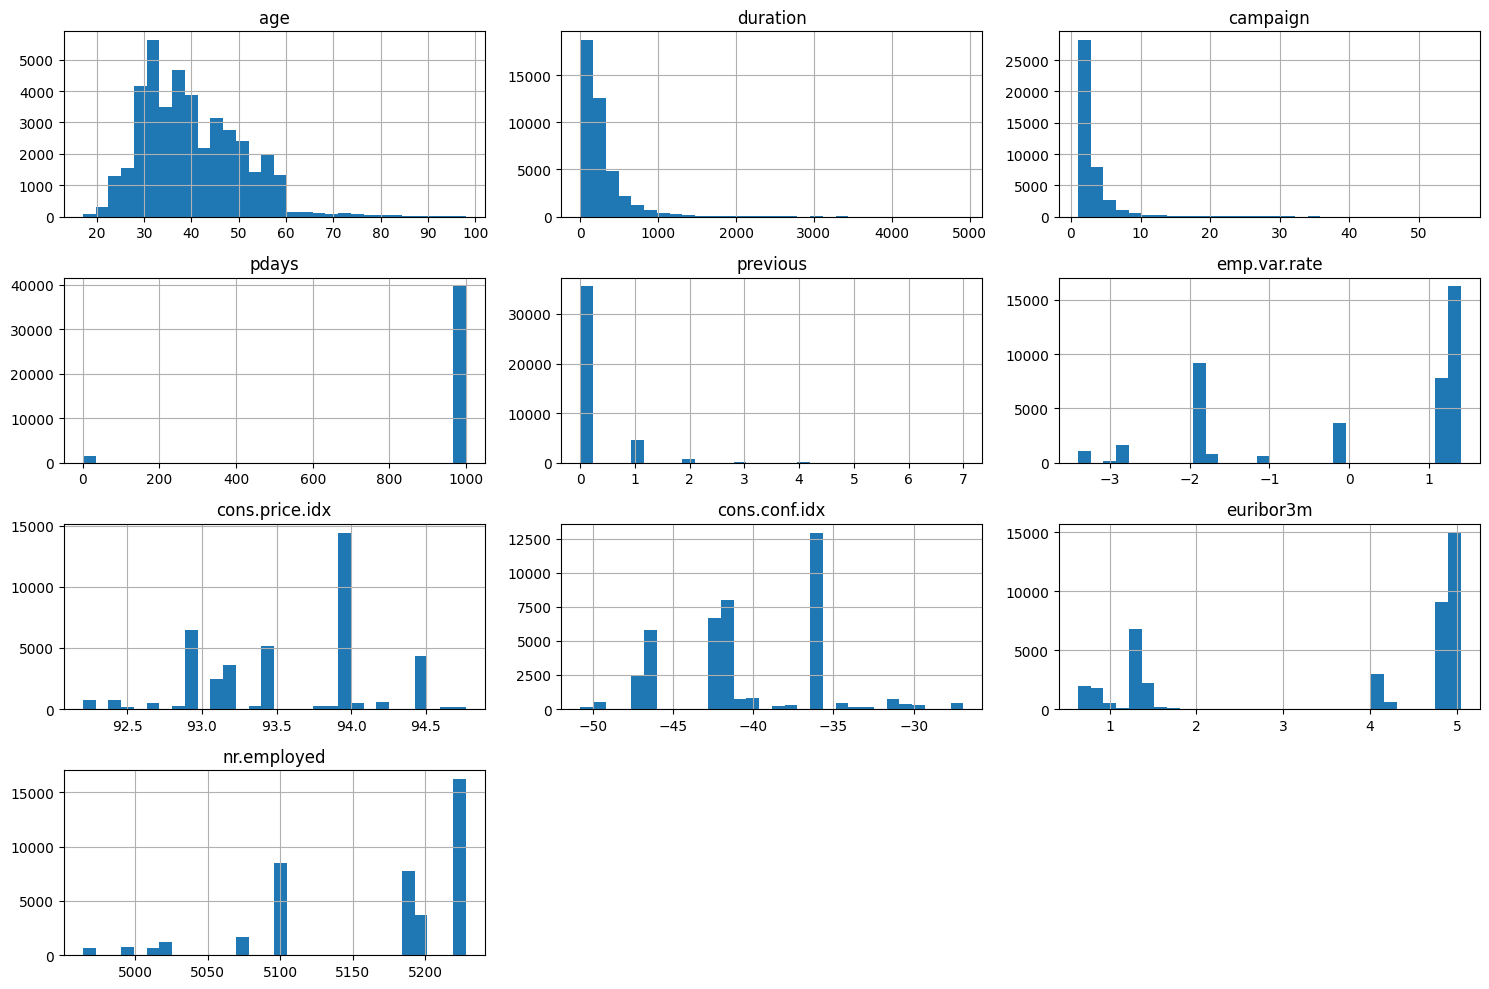

In [ ]:
# Select numeric columns to draw histograms and descriptive statistics tables.
numerical_cols = df.select_dtypes(include=np.number).columns
print("Descriptive statistics for numerical variables:")
display(df[numerical_cols].describe())
print("\nHistogram for digital deformations:")
df[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


In [ ]:
# Select numerical columns again (assuming the original df is still available)
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate the required descriptive statistics
desc_stats = df[numerical_cols].agg(['count','mean', 'min', 'max', 'std']).T

# Rename columns for clarity (optional, but good practice)
desc_stats.columns = ['Count','Mean', 'Min', 'Max', 'Std']

# Format the numerical columns to 3 decimal places and round
# Exclude the 'Count' column from formatting
for col in ['Mean', 'Min', 'Max', 'Std']:
    desc_stats[col] = desc_stats[col].map(lambda x: f'{x:.3f}')


print("Descriptive statistics for numerical variables (formatted and transposed):")
display(desc_stats)

Descriptive statistics for numerical variables (formatted and transposed):


,Count,Mean,Min,Max,Std
age,41188.0,40.024,17.000,98.000,10.421
duration,41188.0,258.285,0.000,4918.000,259.279
campaign,41188.0,2.568,1.000,56.000,2.770
pdays,41188.0,962.475,0.000,999.000,186.911
previous,41188.0,0.173,0.000,7.000,0.495
emp.var.rate,41188.0,0.082,-3.400,1.400,1.571
cons.price.idx,41188.0,93.576,92.201,94.767,0.579
cons.conf.idx,41188.0,-40.503,-50.800,-26.900,4.628
euribor3m,41188.0,3.621,0.634,5.045,1.734
nr.employed,41188.0,5167.036,4963.600,5228.100,72.252


In [ ]:
# NaN: not at number
print("\nColumns",list(df.columns))


Columns ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [ ]:
# Statistics of outcome variable (y) and calculation of proportion
outcome_counts = df['y'].value_counts()
outcome_proportions = df['y'].value_counts(normalize=True)

print("Counts:")
display(outcome_counts)

print("\nProportions:")
display(outcome_proportions)

Counts:


,count
y,
no,36548
yes,4640



Proportions:


,proportion
y,
no,0.887346
yes,0.112654


In [ ]:
# Tính tổng số giá trị thiếu cho mỗi cột
missing_values = df.isnull().sum()

print("Tổng số giá trị thiếu cho mỗi cột:")
display(missing_values)

Tổng số giá trị thiếu cho mỗi cột:


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
# dữ liệu chống đã đc ghi bằng unknown cần trực quan hóa dữ liệu để show dl trống


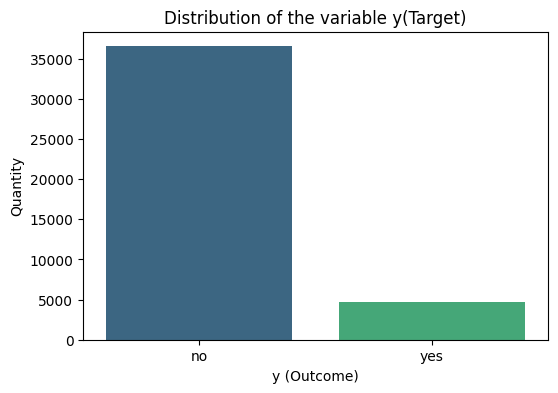

In [ ]:
# Plot the distribution of the variable 'y' (target)
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, hue='y', palette='viridis', legend=False)
plt.title('Distribution of the variable y(Target)')
plt.xlabel('y (Outcome)')
plt.ylabel('Quantity')
plt.show()


In [ ]:
# dạng str là biểu đồ cột or tròn (nếu là %)
# biến dạng số dùng histogram để miêu tả

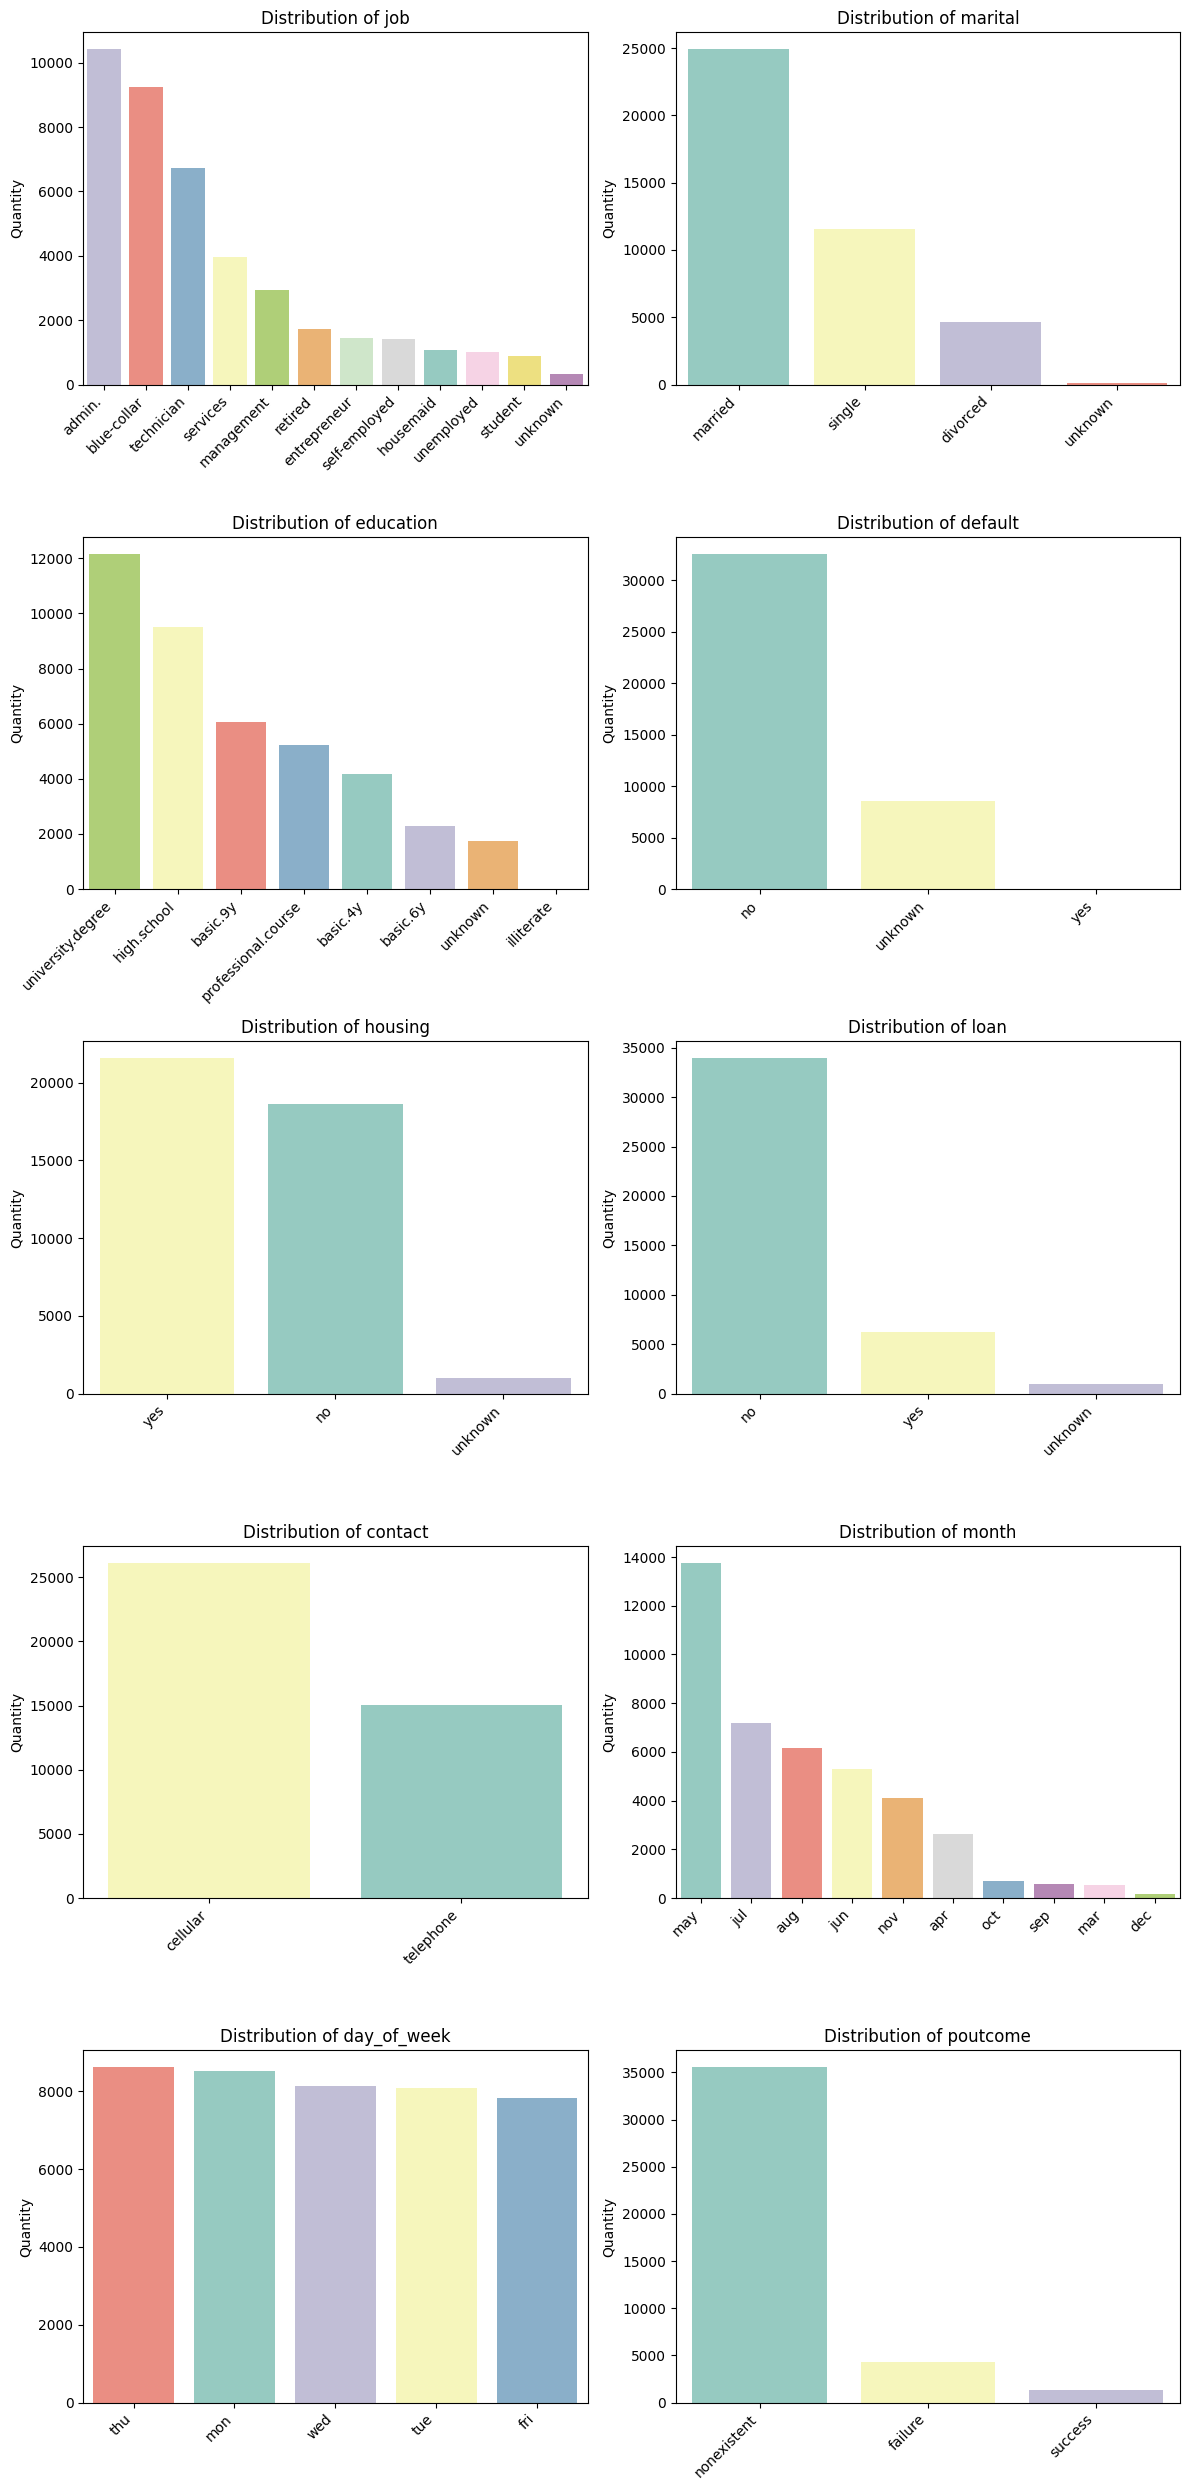

In [ ]:
# categorical data description (str format)
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
n_cols = 2  # Set to 2 columns
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 5)) # Adjust figure size for 2 columns

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=col, data=df, palette='Set3',
                  order=df[col].value_counts().index, hue=col, legend=False) # Add hue and remove legend
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('')
    plt.ylabel('Quantity')

plt.tight_layout()
plt.show()

In [ ]:
# nonexistent: ko liên lạc => đổi thành biến nhị phần là trc đấy đã từng liên hệ hay chưa (bảng distribution of poutcome)
# biến nhị phân: với lớp đc qtam là 1 ko qtam là 0 (cần xác định đối tượng quan tâm)
# thay biến unknown thành NaN để xử lý dl tốt hơn
# data cleaning process
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
# 1) BASIC CLEANING
# - Replace 'unknown' -> NaN (to handle missing correctly)
# - Remove 'duration' column (to avoid data leakage)
# - Check for missing
df = df.replace('unknown', np.nan)
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
print("\nMissing after 'unknown'->NaN (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
# 2) SPECIAL PROCESSING BY EDA
# - pdays: 999 -> NaN; create flag was_contacted_before (0/1)
# - Log-transform: campaign, previous -> reduce outlier
# - Type 'default' if almost constant
# - Group rare in job/education/poutcome

if 'pdays' in df.columns:
    df['pdays'] = df['pdays'].replace(999, np.nan)
    df['was_contacted_before'] = np.where(df['pdays'].isna(), 0, 1).astype(int)
for col in ['campaign', 'previous']:
    if col in df.columns:
        df[col + '_log'] = np.log1p(df[col])
# Type 'default' if > 95% of a value (almost no information)
if 'default' in df.columns:
    top_ratio = df['default'].value_counts(normalize=True, dropna=False).max()
    if top_ratio > 0.95:
        df = df.drop(columns=['default'])
# Rare clustering to reduce One-Hot (binary variable) sparsity
def lump_rare(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    rare = freq[freq < min_freq].index
    return series.where(~series.isin(rare), other='other')
for c in ['job', 'education', 'poutcome']:
    if c in df.columns:
        df[c] = lump_rare(df[c], min_freq=0.01)
print("\nAfter feature engineering:")
print("Columns:", len(df.columns))
# 3) SPLIT TRAIN/TEST (stratify=y)
X = df.drop(columns=['y'])
y = (df['y'] == 'yes').astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
print("\nTrain/Test shapes:", X_train.shape, X_test.shape)
print("Target distribution (train):")
print(y_train.value_counts(normalize=True))
num_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print("\nNumeric cols ({}):".format(len(num_cols)), num_cols)
print("Categorical cols ({}):".format(len(cat_cols)), cat_cols)

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]),
    columns=num_cols, index=X_train.index)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]),
    columns=num_cols, index=X_test.index)

X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_cols]),
    columns=cat_cols, index=X_train.index)
X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]),
    columns=cat_cols, index=X_test.index)
# 4) SCALE NUMERIC
scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num),
    columns=num_cols, index=X_train.index)
X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num),
    columns=num_cols, index=X_test.index)
# 5) ONE-HOT ENCODE CATEGORICAL
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
X_train_cat_encoded = pd.DataFrame(ohe.fit_transform(X_train_cat),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index)
X_test_cat_encoded = pd.DataFrame(ohe.transform(X_test_cat),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index)
# Merge processed data
X_train_prepared = pd.concat([X_train_num_scaled, X_train_cat_encoded], axis=1)
X_test_prepared  = pd.concat([X_test_num_scaled,  X_test_cat_encoded],  axis=1)
print("\n PREPROCESSING DONE")
print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)


Missing after 'unknown'->NaN (top 10):
default        8597
education      1731
housing         990
loan            990
job             330
marital          80
age               0
contact           0
month             0
day_of_week       0
dtype: int64

After feature engineering:
Columns: 23

Train/Test shapes: (32950, 22) (8238, 22)
Target distribution (train):
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

Numeric cols (12): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'campaign_log', 'previous_log']
Categorical cols (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

 PREPROCESSING DONE
X_train_prepared: (32950, 59)
X_test_prepared : (8238, 59)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# STEP 5 — EVALUATION (ENHANCED)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             average_precision_score)
import numpy as np
import pandas as pd
from sklearn.metrics import RocCurveDisplay
COST_FP = 1   # 1 cuộc gọi lãng phí
COST_FN = 4   # 1 khách hàng tiềm năng bị bỏ lỡ (thường đắt hơn)

def eval_model(y_true, y_pred, y_proba, name):
    # core metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    # AUCs (lưu ý: cần cả 2 lớp xuất hiện trong y_true)
    try:
        roc_auc = roc_auc_score(y_true, y_proba)
    except ValueError:
        roc_auc = np.nan
    try:
        pr_auc  = average_precision_score(y_true, y_proba)  # PR-AUC
    except ValueError:
        pr_auc = np.nan

    # confusion matrix & rates
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0    # recall
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0    # specificity
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    bal_acc = (tpr + tnr) / 2 if (tpr + tnr) > 0 else 0.0

    # business cost
    total_cost = COST_FP * fp + COST_FN * fn

    # display
    print(f"\n=== {name} ===")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall (TPR)   : {rec:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"ROC AUC        : {roc_auc:.4f}")
    print(f"PR  AUC        : {pr_auc:.4f}")
    print(f"Specificity(TNR): {tnr:.4f} | FPR: {fpr:.4f} | FNR: {fnr:.4f}")
    print(f"Balanced Acc   : {bal_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"Support (pos={tp+fn}, neg={tn+fp})")
    print(f"Estimated Cost : FP*{COST_FP} + FN*{COST_FN} = {total_cost}")

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc,
        'Specificity': tnr,
        'FPR': fpr,
        'FNR': fnr,
        'Balanced_Acc': bal_acc,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Support_Pos': tp + fn,
        'Support_Neg': tn + fp,
        'Cost': total_cost
    }

# ---- Predict & evaluate cho 2 mô hình baseline của bạn ----
# Assuming you have already trained dt_base and log_base
# y_pred_dt_base  = dt_base.predict(X_test_prepared)
# y_proba_dt_base = dt_base.predict_proba(X_test_prepared)[:, 1]

# y_pred_log_base  = log_base.predict(X_test_prepared)
# y_proba_log_base = log_base.predict_proba(X_test_prepared)[:, 1]

# results_base = []
# results_base.append(eval_model(y_test, y_pred_dt_base,  y_proba_dt_base,  "Decision Tree (baseline, entropy)"))
# results_base.append(eval_model(y_test, y_pred_log_base, y_proba_log_base, "Logistic Regression (baseline)"))

# results_base_df = pd.DataFrame(results_base)
# display(results_base_df.sort_values(['Balanced_Acc','PR_AUC','ROC_AUC'], ascending=False))

In [ ]:
# Decision Tree (baseline)
dt_base = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    min_samples_leaf=7,
    random_state=42)
dt_base.fit(X_train_prepared, y_train)
# Logistic Regression (baseline)
log_base = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    random_state=42)
log_base.fit(X_train_prepared, y_train)
print("Trained baseline: DT_base & LR_base")

Trained baseline: DT_base & LR_base


In [ ]:
# EVALUATION (ENHANCED)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             average_precision_score)
import numpy as np
import pandas as pd
COST_FP = 1   # 1 wasted call
COST_FN = 4   # 1 missed lead
def eval_model(y_true, y_pred, y_proba, name):
    # core metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    try:
        roc_auc = roc_auc_score(y_true, y_proba)
    except ValueError:
        roc_auc = np.nan
    try:
        pr_auc  = average_precision_score(y_true, y_proba)
    except ValueError:
        pr_auc = np.nan

    # confusion matrix & rates
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    bal_acc = (tpr + tnr) / 2 if (tpr + tnr) > 0 else 0.0
    # business cost
    total_cost = COST_FP * fp + COST_FN * fn
    # display
    print(f"\n=== {name} ===")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall (TPR)   : {rec:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"ROC AUC        : {roc_auc:.4f}")
    print(f"PR  AUC        : {pr_auc:.4f}")
    print(f"Specificity(TNR): {tnr:.4f} | FPR: {fpr:.4f} | FNR: {fnr:.4f}")
    print(f"Balanced Acc   : {bal_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"Support (pos={tp+fn}, neg={tn+fp})")
    print(f"Estimated Cost : FP*{COST_FP} + FN*{COST_FN} = {total_cost}")
    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc,
        'Specificity': tnr,
        'FPR': fpr,
        'FNR': fnr,
        'Balanced_Acc': bal_acc,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Support_Pos': tp + fn,
        'Support_Neg': tn + fp,
        'Cost': total_cost
    }
# Predict and evaluate 2 baseline models
y_pred_dt_base  = dt_base.predict(X_test_prepared)
y_proba_dt_base = dt_base.predict_proba(X_test_prepared)[:, 1]
y_pred_log_base  = log_base.predict(X_test_prepared)
y_proba_log_base = log_base.predict_proba(X_test_prepared)[:, 1]
results_base = []
results_base.append(eval_model(y_test, y_pred_dt_base,  y_proba_dt_base,  "Decision Tree (baseline, entropy)"))
results_base.append(eval_model(y_test, y_pred_log_base, y_proba_log_base, "Logistic Regression (baseline)"))
results_base_df = pd.DataFrame(results_base)
display(results_base_df.sort_values(['Balanced_Acc','PR_AUC','ROC_AUC'], ascending=False))



=== Decision Tree (baseline, entropy) ===
Accuracy       : 0.8999
Precision      : 0.6900
Recall (TPR)   : 0.2015
F1-score       : 0.3119
ROC AUC        : 0.7857
PR  AUC        : 0.4168
Specificity(TNR): 0.9885 | FPR: 0.0115 | FNR: 0.7985
Balanced Acc   : 0.5950
Confusion Matrix:
 [[7226   84]
 [ 741  187]]
TP=187, FP=84, FN=741, TN=7226
Support (pos=928, neg=7310)
Estimated Cost : FP*1 + FN*4 = 3048

=== Logistic Regression (baseline) ===
Accuracy       : 0.9013
Precision      : 0.6976
Recall (TPR)   : 0.2188
F1-score       : 0.3331
ROC AUC        : 0.8009
PR  AUC        : 0.4642
Specificity(TNR): 0.9880 | FPR: 0.0120 | FNR: 0.7812
Balanced Acc   : 0.6034
Confusion Matrix:
 [[7222   88]
 [ 725  203]]
TP=203, FP=88, FN=725, TN=7222
Support (pos=928, neg=7310)
Estimated Cost : FP*1 + FN*4 = 2988


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Specificity,FPR,FNR,Balanced_Acc,TP,FP,FN,TN,Support_Pos,Support_Neg,Cost
1,Logistic Regression (baseline),0.901311,0.697595,0.218750,0.333060,0.800854,0.464213,0.987962,0.012038,0.781250,0.603356,203,88,725,7222,928,7310,2988
0,"Decision Tree (baseline, entropy)",0.899854,0.690037,0.201509,0.311927,0.785747,0.416755,0.988509,0.011491,0.798491,0.595009,187,84,741,7226,928,7310,3048


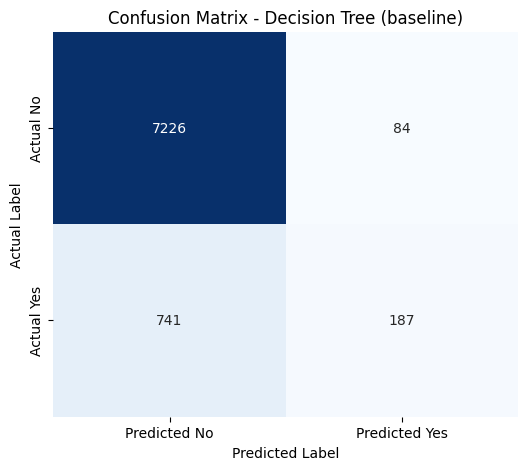

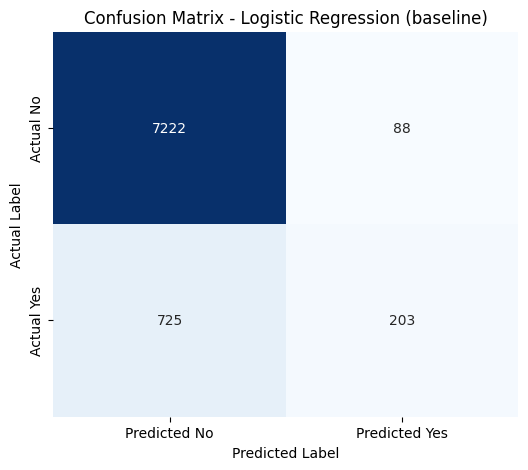

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix cho Decision Tree
cm_dt_base = confusion_matrix(y_test, y_pred_dt_base)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt_base, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - Decision Tree (baseline)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Confusion matrix cho Logistic Regression
cm_log_base = confusion_matrix(y_test, y_pred_log_base)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_base, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix - Logistic Regression (baseline)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

<Figure size 700x600 with 0 Axes>

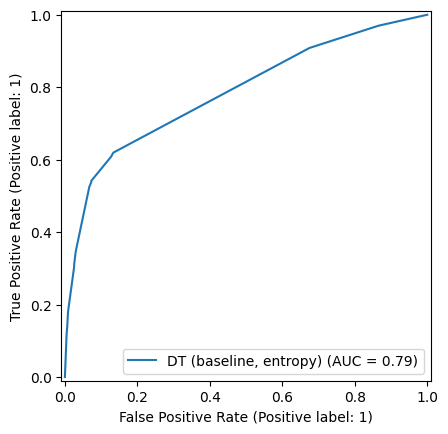

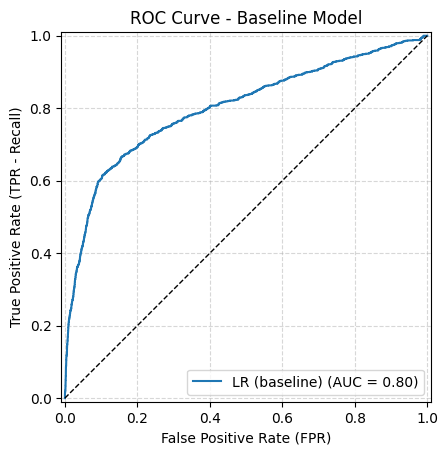

In [ ]:
# ROC CURVE (BASELINE)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(7,6))
RocCurveDisplay.from_predictions(y_test, y_proba_dt_base,  name="DT (baseline, entropy)")
RocCurveDisplay.from_predictions(y_test, y_proba_log_base, name="LR (baseline)")
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.title("ROC Curve - Baseline Model")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR - Recall)")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# GRID SEARCH (DECISION TREE, ENTROPY)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
param_grid_dt = {
    'max_depth': [4, 6, 8, 12, 16],
    'min_samples_leaf': [2, 3, 5, 8, 15, 30],
    'min_samples_split': [5, 10, 20, 40, 80],
    'class_weight': ['balanced'],
    'ccp_alpha': [0.0, 0.0002, 0.0008, 0.002, 0.003]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_train_prepared, y_train)
best_tree = grid_dt.best_estimator_
print("\n GridSearch DT done")
print("Best params:", grid_dt.best_params_)
print("Best CV ROC-AUC:", grid_dt.best_score_)
# Test set
from sklearn.metrics import roc_auc_score
y_proba_dt_best = best_tree.predict_proba(X_test_prepared)[:, 1]
y_pred_dt_best  = (y_proba_dt_best >= 0.5).astype(int)
print("\n=== Decision Tree (best on test, th=0.5) ===")
_ = eval_model(y_test, y_pred_dt_best, y_proba_dt_best, "DT (best, entropy)")

import joblib
# Lưu biến 'best_tree' vào file 'my_best_model.joblib' trên Drive
joblib.dump(best_tree, '/content/drive/MyDrive/my_best_model.joblib')

print("✅✅✅ ĐÃ LƯU MODEL VÀO GOOGLE DRIVE!")


Fitting 5 folds for each of 750 candidates, totalling 3750 fits


KeyboardInterrupt: 

In [ ]:
import joblib

path_to_model = "/content/drive/MyDrive/my_best_model.joblib"
print("Đang tải model đã lưu...")
best_tree = joblib.load(path_to_model)
print("✅ Tải xong! Biến 'best_tree' đã sẵn sàng!")

Đang tải model đã lưu...
✅ Tải xong! Biến 'best_tree' đã sẵn sàng!


In [ ]:
print(best_tree)
# Giả sử bro đã có sẵn X_test_prepared và y_test từ các bước trước
from sklearn.metrics import roc_auc_score

print("Đang chạy dự đoán trên tập test...")
y_proba_dt_best = best_tree.predict_proba(X_test_prepared)[:, 1]
y_pred_dt_best  = (y_proba_dt_best >= 0.5).astype(int)

print("\n=== Decision Tree (best on test, th=0.5) ===")

# Gọi lại hàm eval_model mà bro đã định nghĩa ở đâu đó bên trên
# (Hàm này sẽ in ra Accuracy, Precision, Recall, Confusion Matrix...)
_ = eval_model(y_test, y_pred_dt_best, y_proba_dt_best, "DT (best, entropy)")

DecisionTreeClassifier(ccp_alpha=0.0008, class_weight='balanced',
                       criterion='entropy', max_depth=16, min_samples_leaf=30,
                       min_samples_split=5, random_state=42)
Đang chạy dự đoán trên tập test...

=== Decision Tree (best on test, th=0.5) ===

=== DT (best, entropy) ===
Accuracy       : 0.8218
Precision      : 0.3513
Recall (TPR)   : 0.6875
F1-score       : 0.4650
ROC AUC        : 0.8078
PR  AUC        : 0.4483
Specificity(TNR): 0.8389 | FPR: 0.1611 | FNR: 0.3125
Balanced Acc   : 0.7632
Confusion Matrix:
 [[6132 1178]
 [ 290  638]]
TP=638, FP=1178, FN=290, TN=6132
Support (pos=928, neg=7310)
Estimated Cost : FP*1 + FN*4 = 2338


In [ ]:

# GRID SEARCH (LOGISTIC REGRESSION)
from sklearn.linear_model import LogisticRegression
param_grids_log = [
    {   'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
        'class_weight': [None, 'balanced'],
        'max_iter': [2000],
    },
    {   'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
        'class_weight': [None, 'balanced'],
        'max_iter': [2000],
    },
    {   'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
        'class_weight': [None, 'balanced'],
        'max_iter': [2000],
},
]
grid_log = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grids_log,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1)
grid_log.fit(X_train_prepared, y_train)
best_log = grid_log.best_estimator_
print("\n GridSearch Logistic done")
print("Best params:", grid_log.best_params_)
print("Best CV ROC-AUC:", grid_log.best_score_)
y_proba_log_best = best_log.predict_proba(X_test_prepared)[:, 1]
y_pred_log_best  = (y_proba_log_best >= 0.5).astype(int)
print("\n=== Logistic Regression (best on test, th=0.5) ===")
_ = eval_model(y_test, y_pred_log_best, y_proba_log_best, "Logistic (best)")

#=== THÊM 3 DÒNG NÀY VÀO CUỐI Ô ĐỂ LƯU LẠI 💾 ===
import joblib
#Tạo đường dẫn, lưu vào đúng thư mục bro muốn
path_to_save_log = "/content/drive/MyDrive/Colab Notebooks/best_log_model.joblib"
joblib.dump(best_log, path_to_save_log)

print(f"✅✅✅ ĐÃ LƯU MODEL LOGISTIC VÀO: {path_to_save_log}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits

✅ GridSearch Logistic xong
Best params: {'C': 0.5, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.790252432324472

=== Logistic Regression (best on test, th=0.5) ===

=== Logistic (best) ===
Accuracy       : 0.8333
Precision      : 0.3646
Recall (TPR)   : 0.6455
F1-score       : 0.4660
ROC AUC        : 0.8011
PR  AUC        : 0.4594
Specificity(TNR): 0.8572 | FPR: 0.1428 | FNR: 0.3545
Balanced Acc   : 0.7513
Confusion Matrix:
 [[6266 1044]
 [ 329  599]]
TP=599, FP=1044, FN=329, TN=6266
Support (pos=928, neg=7310)
Estimated Cost : FP*1 + FN*5 = 2689
✅✅✅ ĐÃ LƯU MODEL LOGISTIC VÀO: /content/drive/MyDrive/Colab Notebooks/best_log_model.joblib


In [ ]:
# === BƯỚC 8 MỚI (CHẠY NHANH) ===
import joblib
# Lấy lại đường dẫn file đã lưu
path_to_log_model = "/content/drive/MyDrive/Colab Notebooks/best_log_model.joblib"

print("Đang tải model Logistic từ Drive...")
# Tải "nồi súp" về, gán lại vào biến y hệt tên cũ
best_log = joblib.load(path_to_log_model)

print("✅ Tải xong! Model 'best_log' đã sẵn sàng.")
print(best_log) # In ra cấu hình để xác nhận
# Chạy đánh giá như bình thường
y_proba_log_best = best_log.predict_proba(X_test_prepared)[:, 1]
y_pred_log_best  = (y_proba_log_best >= 0.5).astype(int)

print("\n=== Logistic Regression (best on test, th=0.5) ===")
_ = eval_model(y_test, y_pred_log_best, y_proba_log_best, "Logistic (best)")

Đang tải model Logistic từ Drive...
✅ Tải xong! Model 'best_log' đã sẵn sàng.
LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000,
                   solver='liblinear')

=== Logistic Regression (best on test, th=0.5) ===

=== Logistic (best) ===
Accuracy       : 0.8333
Precision      : 0.3646
Recall (TPR)   : 0.6455
F1-score       : 0.4660
ROC AUC        : 0.8011
PR  AUC        : 0.4594
Specificity(TNR): 0.8572 | FPR: 0.1428 | FNR: 0.3545
Balanced Acc   : 0.7513
Confusion Matrix:
 [[6266 1044]
 [ 329  599]]
TP=599, FP=1044, FN=329, TN=6266
Support (pos=928, neg=7310)
Estimated Cost : FP*1 + FN*4 = 2360


In [ ]:

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
# COST-SENSITIVE THRESHOLD TUNING
# Cost configuration
COST_FP = 2.0
COST_FN = 15.0
COST_TP = -4.0
COST_TN = 0.0
def expected_cost(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = tp*COST_TP + fp*COST_FP + fn*COST_FN + tn*COST_TN
    return total_cost / len(y_true)
def sweep_thresholds(y_true, y_proba, name):
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for t in thresholds:
        rows.append({'threshold': t, 'avg_cost': expected_cost(y_true, y_proba, t)})
    df_cost = pd.DataFrame(rows).sort_values('avg_cost')
    print(f"\nTop 5 threshold (min avg cost) — {name}")
    display(df_cost.head(5))
    best_t  = float(df_cost.iloc[0]['threshold'])
    best_ac = float(df_cost.iloc[0]['avg_cost'])
    return best_t, best_ac, df_cost
dt_best_th,  dt_best_cost,  dt_cost_df  = sweep_thresholds(y_test, y_proba_dt_best,  "DT (best)")
log_best_th, log_best_cost, log_cost_df = sweep_thresholds(y_test, y_proba_log_best, "Logistic (best)")


Top 5 threshold (min avg cost) — DT (best)


,threshold,avg_cost
40,0.41,0.504249
41,0.42,0.504249
42,0.43,0.504249
49,0.50,0.504249
48,0.49,0.504249



Top 5 threshold (min avg cost) — Logistic (best)


,threshold,avg_cost
44,0.45,0.547949
60,0.61,0.558509
55,0.56,0.558631
52,0.53,0.558752
42,0.43,0.559480


In [ ]:
# PICK WINNER (Base on AVG COST)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def metrics_at(y_true, y_proba, th, name):
    y_pred = (y_proba >= th).astype(int)
    return {
        'Model': name,
        'Threshold': th,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_proba),
        'Avg_Cost': expected_cost(y_true, y_proba, th)
    }

summary = pd.DataFrame([
    metrics_at(y_test, y_proba_dt_best,  dt_best_th,  "DT (best @th*)"),
    metrics_at(y_test, y_proba_log_best, log_best_th, "Logistic (best @th*)")
]).sort_values('Avg_Cost')
display(summary)

winner_row = summary.iloc[0]
print(f"\n WINNER: {winner_row['Model']}  @ threshold={winner_row['Threshold']:.3f}  "
      f"(Avg Cost={winner_row['Avg_Cost']:.6f})")

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,Avg_Cost
0,DT (best @th*),0.41,0.821801,0.351322,0.687500,0.465015,0.807844,0.504249
1,Logistic (best @th*),0.45,0.802015,0.322025,0.685345,0.438167,0.801104,0.547949



 WINNER: DT (best @th*)  @ threshold=0.410  (Avg Cost=0.504249)


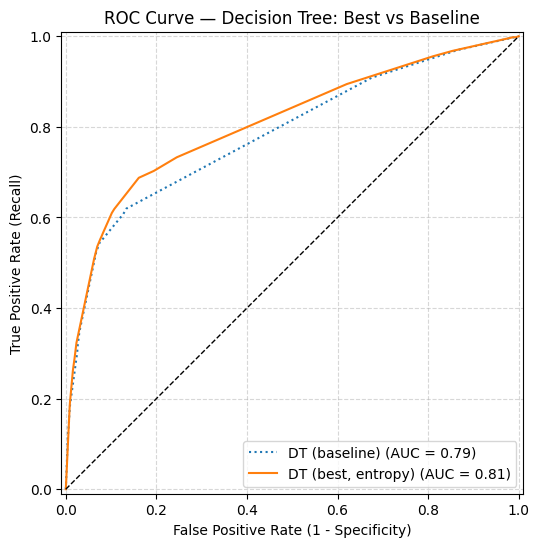

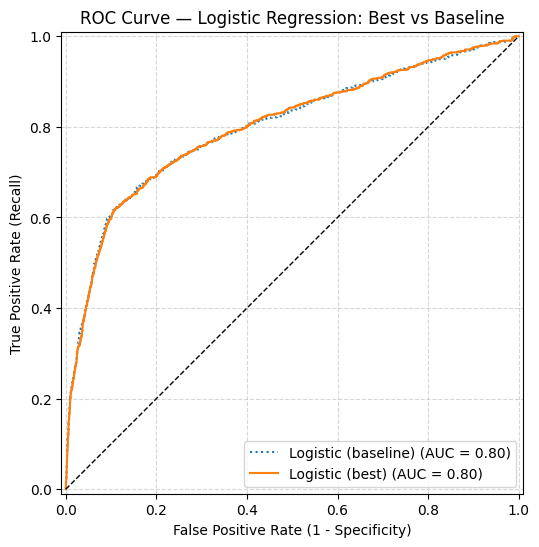

In [ ]:
# ROC CURVE (BEST MODELS)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# ROC Plot for Decision Tree (Baseline vs Best)
plt.figure(figsize=(7,6))
# Plot baseline DT ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_dt_base, name="DT (baseline)",  linestyle=':', ax=plt.gca())
# Plot best DT ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_dt_best,  name="DT (best, entropy)", ax=plt.gca())
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.title("ROC Curve — Decision Tree: Best vs Baseline")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ROC Plot for Logistic Regression (Baseline vs Best)
plt.figure(figsize=(7,6))
# Plot baseline Logistic Regression ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_log_base, name="Logistic (baseline)", linestyle=':', ax=plt.gca())
# Plot best Logistic Regression ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_log_best, name="Logistic (best)", ax=plt.gca())
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.title("ROC Curve — Logistic Regression: Best vs Baseline")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# ============================================================
# STEP 12 — INTERPRETABILITY
# ============================================================
import numpy as np

# Feature importance — Decision Tree
fi = pd.Series(best_tree.feature_importances_, index=X_train_prepared.columns)\
       .sort_values(ascending=False).head(25)
print("\nTop 25 Feature Importances — Decision Tree (best):")
display(fi)

# Coefficients — Logistic (theo độ lớn tuyệt đối)
try:
    coef = pd.Series(best_log.coef_[0], index=X_train_prepared.columns)\
             .sort_values(key=np.abs, ascending=False).head(25)
    print("\nTop 25 Coefficients (|value|) — Logistic (best):")
    display(coef)
except Exception as e:
    print("Không hiển thị được coefficients:", e)


Top 25 Feature Importances — Decision Tree (best):


,0
nr.employed,0.657553
cons.conf.idx,0.125465
euribor3m,0.058600
was_contacted_before,0.044662
cons.price.idx,0.043518
month_oct,0.021562
age,0.013200
campaign,0.013152
education_university.degree,0.008386
contact_telephone,0.005931



Top 25 Coefficients (|value|) — Logistic (best):


,0
emp.var.rate,-2.231021
month_mar,1.254638
cons.price.idx,1.092304
month_jun,-0.790276
month_may,-0.672513
month_nov,-0.573757
month_aug,0.448417
month_dec,0.431471
euribor3m,0.411422
education_other,0.410672


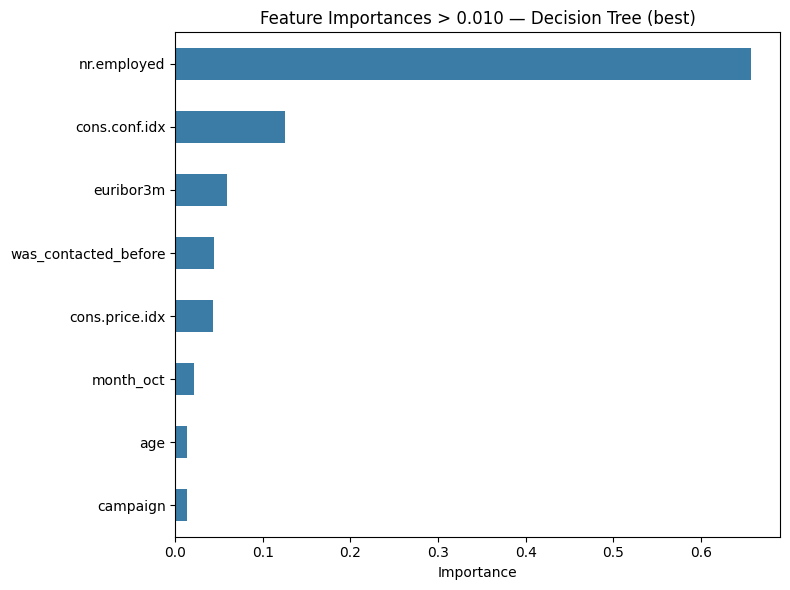


 Showing 8 significant features (importance > 0.01).


,0
nr.employed,0.657553
cons.conf.idx,0.125465
euribor3m,0.058600
was_contacted_before,0.044662
cons.price.idx,0.043518
month_oct,0.021562
age,0.013200
campaign,0.013152


In [ ]:
# Show only meaningful features (importance > threshold)
threshold = 0.01
fi_sig = fi[fi > threshold].sort_values(ascending=False)

if fi_sig.empty:
    print(f"No features exceed the threshold ({threshold}) — showing top 20 instead.")
    fi_sig = fi.head(20)

plt.figure(figsize=(8, 6))
fi_sig.sort_values().plot(kind='barh', color="#3A7CA5")
plt.title(f"Feature Importances > {threshold:.3f} — Decision Tree (best)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(f"\n Showing {len(fi_sig)} significant features (importance > {threshold}).")
display(fi_sig)

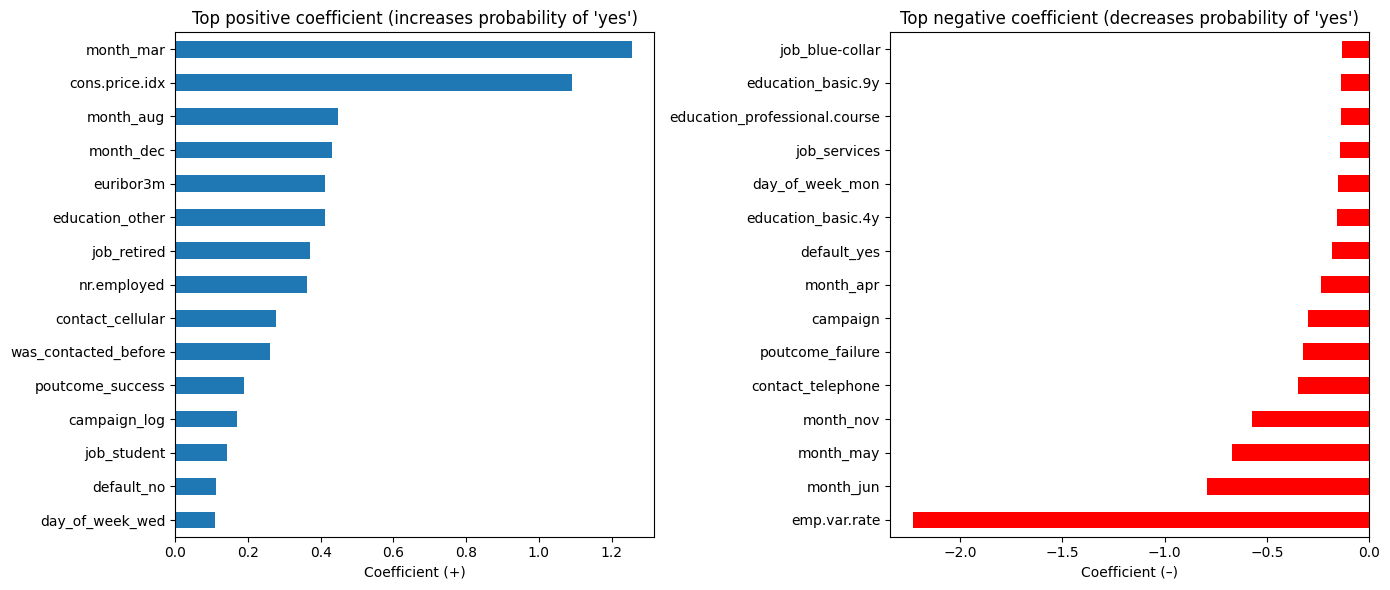

In [ ]:
# Logistic Regression: Coefficient Bars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    model_log = best_log
except NameError:
    model_log = log_base

coefs = pd.Series(model_log.coef_[0], index=X_train_prepared.columns)
top_pos = coefs.sort_values(ascending=False).head(15)
top_neg = coefs.sort_values(ascending=True).head(15)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)
top_pos.sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title("Top positive coefficient (increases probability of 'yes')")
axes[0].set_xlabel("Coefficient (+)")
top_neg.sort_values().plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title("Top negative coefficient (decreases probability of 'yes')")
axes[1].set_xlabel("Coefficient (–)")
plt.tight_layout()
plt.show()

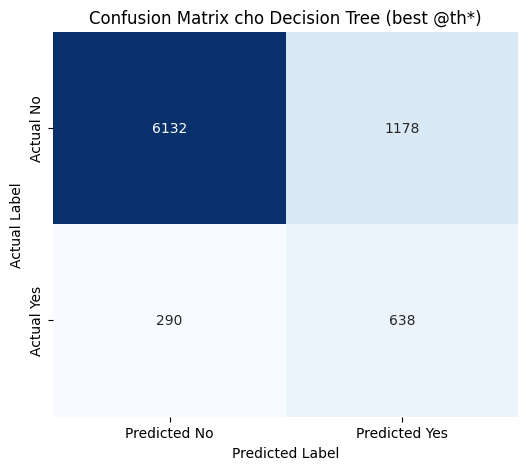

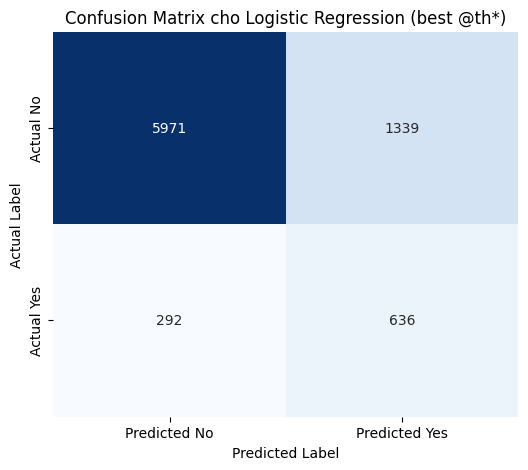

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tính lại confusion matrix cho mô hình Decision Tree tốt nhất với ngưỡng tối ưu
cm_dt_best_tuned = confusion_matrix(y_test, (y_proba_dt_best >= dt_best_th).astype(int))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt_best_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix cho Decision Tree (best @th*)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Tính lại confusion matrix cho mô hình Logistic Regression tốt nhất với ngưỡng tối ưu
cm_log_best_tuned = confusion_matrix(y_test, (y_proba_log_best >= log_best_th).astype(int))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_best_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix cho Logistic Regression (best @th*)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [ ]:
# Hiển thị lại confusion matrix cho mô hình Decision Tree tốt nhất với ngưỡng tối ưu
print("\n=== Confusion Matrix cho Decision Tree (best @th*) ===")
_ = eval_model(y_test, (y_proba_dt_best >= dt_best_th).astype(int), y_proba_dt_best, "DT (best @th*)")


=== Confusion Matrix cho Decision Tree (best @th*) ===

=== DT (best @th*) ===
Accuracy       : 0.8218
Precision      : 0.3513
Recall (TPR)   : 0.6875
F1-score       : 0.4650
ROC AUC        : 0.8078
PR  AUC        : 0.4483
Specificity(TNR): 0.8389 | FPR: 0.1611 | FNR: 0.3125
Balanced Acc   : 0.7632
Confusion Matrix:
 [[6132 1178]
 [ 290  638]]
TP=638, FP=1178, FN=290, TN=6132
Support (pos=928, neg=7310)
Estimated Cost : FP*2.0 + FN*15.0 = 6706.0
